In [1]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions


C:\Users\TANUSHREE\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df=pd.DataFrame()

In [4]:
df['X1']=[1,2,3,4,5,6,6,7,9,9]
df['X2']=[5,3,6,8,1,9,5,8,9,2]
df['label']=[1,1,0,1,0,1,0,1,0,0]


In [5]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

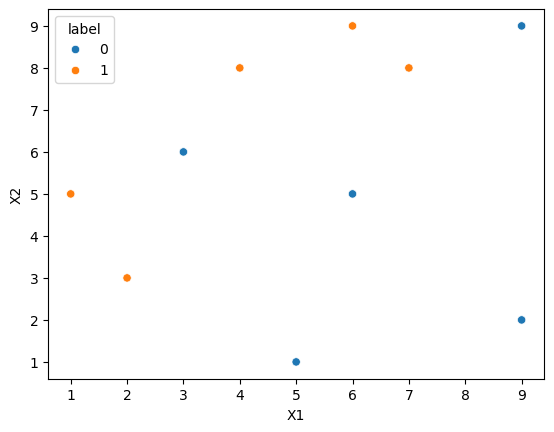

In [7]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [8]:
df['weights']=1/df.shape[0]

In [9]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [10]:
from sklearn.tree import DecisionTreeClassifier
dt1=DecisionTreeClassifier(max_depth=1)#decision stump

In [11]:
X=df.iloc[:,0:2].values
y=df.iloc[:,2].values


In [13]:
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

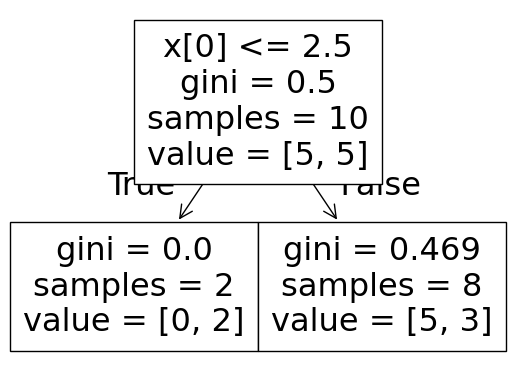

In [14]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

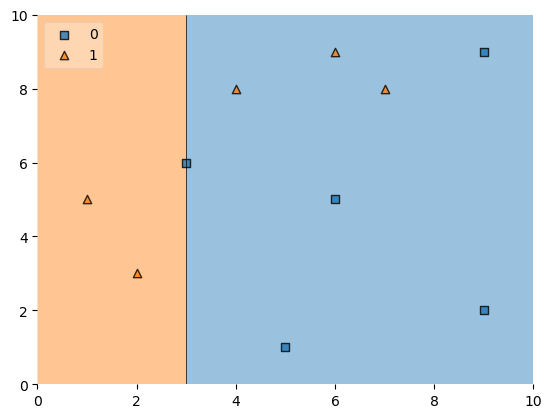

In [18]:
plot_decision_regions(X,y,clf=dt1,legend=2)

In [16]:
df['y_pred']=dt1.predict(X)

In [17]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [62]:
#total 3 mistake 3(0.1)=0.3 =error put in formula and get aplha
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/(error+0.0000001))



# def update_row_weights(row,alpha=0.423):
#     #correct less increase
#     if row['label']==row['y_pred']:
#         return row['weights']*np.exp(-alpha)
#     else:
#         return row['weights']*np.exp(alpha)



# def create_new_dataset(df):
#     indices=[]
#     for i in range(df.shape[0]):
#         a=np.random.random()#this genrates 0 ≤ a < 1
#         for index,row in df.iterrows():
#             if row['cumsum_upper']>a and a>row['cumsum_lower']:
#                 indices.append(index)
#     return indices


In [23]:
alpha1=calculate_model_weight(0.3)

In [24]:
alpha1

np.float64(0.42364893019360184)

In [27]:
#update weights
def update_row_weights(row,alpha=0.423):
    #correct less increase
    if row['label']==row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)
        

In [28]:
df['updated_weights']=df.apply(update_row_weights,axis=1)

In [29]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,0,0.152653
6,6,5,0,0.1,0,0.065508
7,7,8,1,0.1,0,0.152653
8,9,9,0,0.1,0,0.065508
9,9,2,0,0.1,0,0.065508


In [30]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

In [31]:
df['normalized_weights']=df['updated_weights']/df['updated_weights'].sum()

In [32]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,0,0.065508,0.071475
3,4,8,1,0.1,0,0.152653,0.166559
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,0,0.152653,0.166559
6,6,5,0,0.1,0,0.065508,0.071475
7,7,8,1,0.1,0,0.152653,0.166559
8,9,9,0,0.1,0,0.065508,0.071475
9,9,2,0,0.1,0,0.065508,0.071475


In [33]:
df['normalized_weights'].sum()

np.float64(1.0)

In [34]:
df['cumsum_upper']=np.cumsum(df['normalized_weights'])

In [35]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.071475,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,0,0.065508,0.071475,0.214425
3,4,8,1,0.1,0,0.152653,0.166559,0.380983
4,5,1,0,0.1,0,0.065508,0.071475,0.452458
5,6,9,1,0.1,0,0.152653,0.166559,0.619017
6,6,5,0,0.1,0,0.065508,0.071475,0.690492
7,7,8,1,0.1,0,0.152653,0.166559,0.857050
8,9,9,0,0.1,0,0.065508,0.071475,0.928525
9,9,2,0,0.1,0,0.065508,0.071475,1.000000


In [36]:
df['cumsum_lower']=df['cumsum_upper']-df['normalized_weights']

In [37]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,0,0.065508,0.071475,0.214425,0.142950
3,4,8,1,0.1,0,0.152653,0.166559,0.380983,0.214425
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,0,0.152653,0.166559,0.619017,0.452458
6,6,5,0,0.1,0,0.065508,0.071475,0.690492,0.619017
7,7,8,1,0.1,0,0.152653,0.166559,0.857050,0.690492
8,9,9,0,0.1,0,0.065508,0.071475,0.928525,0.857050
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [40]:
#creating new data set by picking random samples
def create_new_dataset(df):
    indices=[]
    for i in range(df.shape[0]):
        a=np.random.random()#this genrates 0 ≤ a < 1
        for index,row in df.iterrows():
            if row['cumsum_upper']>a and a>row['cumsum_lower']:
                indices.append(index)
    return indices


# ✅ What is df.iterrows() ?

# iterrows() is a pandas function that:

# 👉 Iterates (loops) through each row of the DataFrame
# 👉 Returns two things for each row:

# (index, row_data)


In [41]:
index_values=create_new_dataset(df)

In [43]:
index_values

[0, 8, 7, 7, 7, 1, 9, 9, 5, 5]

In [47]:
second_df=df.iloc[index_values,0:4]

In [48]:
second_df

,X1,X2,label,weights
0,1,5,1,0.1
8,9,9,0,0.1
7,7,8,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1
1,2,3,1,0.1
9,9,2,0,0.1
9,9,2,0,0.1
5,6,9,1,0.1
5,6,9,1,0.1


In [51]:
dt2=DecisionTreeClassifier(max_depth=1)

In [52]:
X=second_df.iloc[:,0:2].values
y=second_df.iloc[:,2].values

In [53]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 8.0\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.625, 0.5, '  False')]

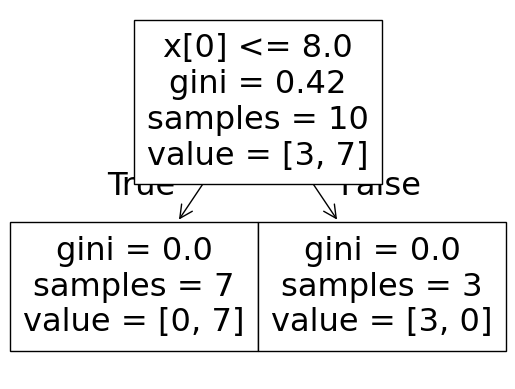

In [55]:
plot_tree(dt2)

<Axes: >

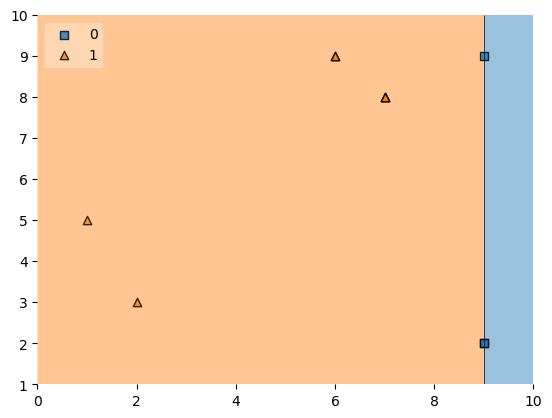

In [56]:
plot_decision_regions(X,y,clf=dt2,legend=2)

In [57]:
second_df['y_pred']=dt2.predict(X)

In [58]:
second_df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
8,9,9,0,0.1,0
7,7,8,1,0.1,1
7,7,8,1,0.1,1
7,7,8,1,0.1,1
1,2,3,1,0.1,1
9,9,2,0,0.1,0
9,9,2,0,0.1,0
5,6,9,1,0.1,1
5,6,9,1,0.1,1


In [61]:
alpha2=calculate_model_weight(0)

In [65]:
# def calculate_model_weight(error):
#     return 0.5*np.log((1-error)/(error+0.0000001))



# def update_row_weights(row,alpha=0.423):
#     #correct less increase
#     if row['label']==row['y_pred']:
#         return row['weights']*np.exp(-alpha)
#     else:
#         return row['weights']*np.exp(alpha)



# def create_new_dataset(df):
#     indices=[]
#     for i in range(df.shape[0]):
#         a=np.random.random()#this genrates 0 ≤ a < 1
#         for index,row in df.iterrows():
#             if row['cumsum_upper']>a and a>row['cumsum_lower']:
#                 indices.append(index)
#     return indices

In [64]:
alpha2

np.float64(8.05904782547916)

In [66]:
def update_row_weights(row,alpha=8.059):
    #correct less increase
    if row['label']==row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)


In [67]:
second_df['update_weights']=second_df.apply(update_row_weights,axis=1)

In [68]:
second_df

,X1,X2,label,weights,y_pred,update_weights
0,1,5,1,0.1,1,0.000032
8,9,9,0,0.1,0,0.000032
7,7,8,1,0.1,1,0.000032
7,7,8,1,0.1,1,0.000032
7,7,8,1,0.1,1,0.000032
1,2,3,1,0.1,1,0.000032
9,9,2,0,0.1,0,0.000032
9,9,2,0,0.1,0,0.000032
5,6,9,1,0.1,1,0.000032
5,6,9,1,0.1,1,0.000032


In [70]:
second_df['normalized_weights']=second_df['update_weights']/second_df['update_weights'].sum()

In [71]:
second_df

,X1,X2,label,weights,y_pred,update_weights,normalized_weights
0,1,5,1,0.1,1,0.000032,0.1
8,9,9,0,0.1,0,0.000032,0.1
7,7,8,1,0.1,1,0.000032,0.1
7,7,8,1,0.1,1,0.000032,0.1
7,7,8,1,0.1,1,0.000032,0.1
1,2,3,1,0.1,1,0.000032,0.1
9,9,2,0,0.1,0,0.000032,0.1
9,9,2,0,0.1,0,0.000032,0.1
5,6,9,1,0.1,1,0.000032,0.1
5,6,9,1,0.1,1,0.000032,0.1


In [72]:
second_df['normalized_weights'].sum()

np.float64(1.0000000000000002)

In [73]:
second_df['cumsum_upper']=np.cumsum(second_df['normalized_weights'])

In [74]:
second_df['cumsum_lower']=second_df['cumsum_upper']-second_df['normalized_weights']

In [75]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,0,0.065508,0.071475,0.214425,0.142950
3,4,8,1,0.1,0,0.152653,0.166559,0.380983,0.214425
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,0,0.152653,0.166559,0.619017,0.452458
6,6,5,0,0.1,0,0.065508,0.071475,0.690492,0.619017
7,7,8,1,0.1,0,0.152653,0.166559,0.857050,0.690492
8,9,9,0,0.1,0,0.065508,0.071475,0.928525,0.857050
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [76]:
index_values=create_new_dataset(second_df)

In [77]:
third_df=second_df.iloc[index_values,[0,1,2,3]]

In [78]:
third_df

,X1,X2,label,weights
9,9,2,0,0.1
9,9,2,0,0.1
5,6,9,1,0.1
1,2,3,1,0.1
1,2,3,1,0.1
5,6,9,1,0.1
1,2,3,1,0.1
9,9,2,0,0.1
1,2,3,1,0.1
8,9,9,0,0.1


In [79]:
dt3=DecisionTreeClassifier(max_depth=1)

In [80]:
X=third_df.iloc[:,0:2].values
y=third_df.iloc[:,2].values

In [82]:
dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 7.5\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.625, 0.5, '  False')]

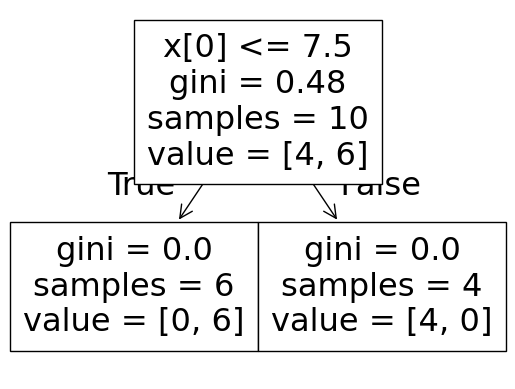

In [83]:
plot_tree(dt3)

<Axes: >

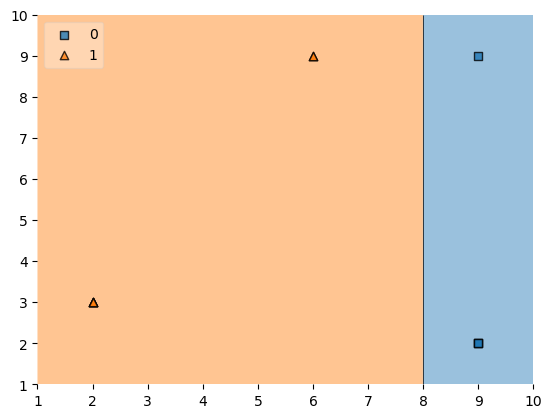

In [85]:
plot_decision_regions(X,y,clf=dt3,legend=2)

In [86]:
third_df['y_pred']=dt3.predict(X)

In [87]:
third_df

,X1,X2,label,weights,y_pred
9,9,2,0,0.1,0
9,9,2,0,0.1,0
5,6,9,1,0.1,1
1,2,3,1,0.1,1
1,2,3,1,0.1,1
5,6,9,1,0.1,1
1,2,3,1,0.1,1
9,9,2,0,0.1,0
1,2,3,1,0.1,1
8,9,9,0,0.1,0


In [88]:
alpha3=calculate_model_weight(0)

In [89]:
alpha3

np.float64(8.05904782547916)

In [90]:
def update_row_weights(row,alpha=8.059):
    #correct less increase
    if row['label']==row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)


In [92]:
third_df['uptaded_weights']=third_df.apply(update_row_weights,axis=1)

In [94]:
third_df

,X1,X2,label,weights,y_pred,uptaded_weights
9,9,2,0,0.1,0,0.000032
9,9,2,0,0.1,0,0.000032
5,6,9,1,0.1,1,0.000032
1,2,3,1,0.1,1,0.000032
1,2,3,1,0.1,1,0.000032
5,6,9,1,0.1,1,0.000032
1,2,3,1,0.1,1,0.000032
9,9,2,0,0.1,0,0.000032
1,2,3,1,0.1,1,0.000032
8,9,9,0,0.1,0,0.000032


In [95]:
third_df['normalized_weights']=third_df['uptaded_weights']/third_df['uptaded_weights'].sum()

In [96]:
third_df['normalized_weights'].sum()

np.float64(1.0000000000000002)

In [97]:
third_df

,X1,X2,label,weights,y_pred,uptaded_weights,normalized_weights
9,9,2,0,0.1,0,0.000032,0.1
9,9,2,0,0.1,0,0.000032,0.1
5,6,9,1,0.1,1,0.000032,0.1
1,2,3,1,0.1,1,0.000032,0.1
1,2,3,1,0.1,1,0.000032,0.1
5,6,9,1,0.1,1,0.000032,0.1
1,2,3,1,0.1,1,0.000032,0.1
9,9,2,0,0.1,0,0.000032,0.1
1,2,3,1,0.1,1,0.000032,0.1
8,9,9,0,0.1,0,0.000032,0.1


In [100]:
third_df['cumsum_upper']=np.cumsum(third_df['normalized_weights'])

In [101]:
third_df['cumsum_lower']=third_df['cumsum_upper']-third_df['normalized_weights']

In [102]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,0,0.065508,0.071475,0.214425,0.142950
3,4,8,1,0.1,0,0.152653,0.166559,0.380983,0.214425
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,0,0.152653,0.166559,0.619017,0.452458
6,6,5,0,0.1,0,0.065508,0.071475,0.690492,0.619017
7,7,8,1,0.1,0,0.152653,0.166559,0.857050,0.690492
8,9,9,0,0.1,0,0.065508,0.071475,0.928525,0.857050
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [103]:
query=np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [104]:
dt2.predict(query)

array([1])

In [105]:
dt3.predict(query)

array([1])

In [106]:

alpha1*1+alpha2*1+alpha3*1

np.float64(16.541744581151924)

In [107]:
np.sign(16.54)

np.float64(1.0)

In [108]:
query=np.array([9,9]).reshape(1,2)

In [109]:
dt1.predict(query)

array([0])

In [110]:
dt2.predict(query)

array([0])

In [111]:
dt3.predict(query)

array([0])

In [112]:
alpha1*(-1)+alpha2*(-1)+alpha3*(-1)

np.float64(-16.541744581151924)

In [113]:
np.sign(-16.54)

np.float64(-1.0)

In [ ]:
#use 1 for +1 and -1 for 0